# Generating temperature timeseries over Brazil using Python


> #### Objectives
> - Understand how downscaling allows more precise results
> - Use exact extract for generating the population weighted temperature timeseries in Salvador
> - Plot the nat and hist-nat results for the climatology of Salvador
> - Generate plots for a region of your choice!
>
> #### Inputs
> - IGR shapefiles
> - DAMIP temperature 2D data
> - Worldpop population data
> - Observed temperature data


### 0. Imports

In [ ]:
import gdown
!pip install exactextract
!pip install rioxarray
!pip install cartopy
!pip install netcdf4
gdown.download(
    "https://raw.githubusercontent.com/vosps/attribution_tutorial/main/timeseries_functions.py",
    "timeseries_functions.py",
    quiet=True
)

In [ ]:
# import python packages
import gdown
import xarray as xr
import pandas as pd
import xarray as xr
import h5py
import numpy as np
import matplotlib.pyplot as plt
from exactextract import exact_extract
import geopandas as gpd
import rioxarray
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from timeseries_functions import process_data,plot_timeseries,plot_climatology,plot_region



### 1. Download and load data

In [ ]:
gdown.download(
    "https://drive.google.com/uc?id=1hVF3ML6ezgz6fln31dGpHcJOdu4FBP-N",
    "CanESM5_historical_temperature_original_resolution.nc",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=1hVF3ML6ezgz6fln31dGpHcJOdu4FBP-N",
    "observed_temperature.nc",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=1K7C5CYAAef8r0qkAJyAK_wyNAowrhUiY",
    "histnat_downscaled.nc",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=1dXc1V5WcIR3ER_KrE4DyJR3kH7ggD2Dk",
    "historical_downscaled.nc",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=1YWXAQQxeL-OqNdRxeyyiBnQQ7B3Gq8nv",
    "pop_density_28deg.nc",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=13pLPN66EIpf-RUmQdzP2Iui0jHzJnbbx",
    "population_density_05deg.nc",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=1Gfd0ApuQRto9How2wWMvrZ7TKSAbDKJF",
    "temperature_observations.nc",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=1TvF-32rf60nlcTFhe9Txlc4J1aovjwsa",
    "shapefile.parquet",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=1l28SSgebwWJC8t6foXlPvHyXk-4azYp0",
    "bias_corrected_not_downscaled.nc",
    quiet=False
)

In [ ]:
############################
# load temperature datasets
############################

# original resolution historical climate
original = xr.open_dataset("CanESM5_historical_temperature_original_resolution.nc", engine="netcdf4")
# downscaled equivalent
historical = xr.open_dataset("historical_downscaled.nc", engine="netcdf4")
natural = xr.open_dataset("histnat_downscaled.nc", engine="netcdf4")
bias_not_downscaled = xr.open_dataset("bias_corrected_not_downscaled.nc", engine="netcdf4")
# observational dataset
observations = xr.open_dataset("temperature_observations.nc", engine="netcdf4")

# population density data
pop_density = xr.open_dataarray("population_density_05deg.nc",engine="netcdf4").isel(lon=slice(0,82))
pop_density_original_resolution = xr.open_dataarray("pop_density_28deg.nc",engine="netcdf4")

# municipality shapefile
shapefile = gpd.read_parquet("shapefile.parquet")



##############################################
# process the data into the appropriate format
##############################################

historical, natural, observations, original, pop_density, pop_density_original_resolution, bias_not_downscaled = process_data(
    historical, natural, observations, original, pop_density, pop_density_original_resolution, bias_not_downscaled
)

# Set index for exactextract
rgi_indexed = shapefile.set_index("rgi")

# get shapefile for Salvador
salvador = shapefile[shapefile['nome_rgi'] == 'Salvador']


### 2. Plot Salvador

In [ ]:
plot_region('Salvador',shapefile, original, historical,bias_not_downscaled)


> Here we have plotted the climate model data over Salvador at the original resolution, after the bias correcting step and after the final downscaling step using the ISIMIP framework. 
>
> Notice how in the original case, the data for Salvador matches exactly with several other regions. Through doing the bias correction method, we find that more precise temperature estimates can be made which is important when interested in temperature-health relationships over small regions and cities.

### 2. Plot population data at same resolution as temperature data

In [ ]:
# plot population density data

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

pop_density.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    norm=LogNorm(vmin=1, vmax=float(pop_density.max())),
    cmap='inferno',
    cbar_kwargs={'label': 'Population density (people/km²)', 'shrink': 0.7}
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='white')
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.3, edgecolor='white')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle='--', color='gray')
gl.xlabel_style = {'color': 'white'}
gl.ylabel_style = {'color': 'white'}

ax.set_title('Population Density', color='white')
plt.show()


### 3. Process the timeseries using exact extract
>
> Exact extract works by doing a weighted mean of grid cells that appear within a shapefile
>
> Exact extract calculates the area of the grid cells inside each shapefile polygon
> the result depends on how the shapefile intersects with each grid cell, e.g. in the image below, only the area highlighted in pink is included in the mean calculation.

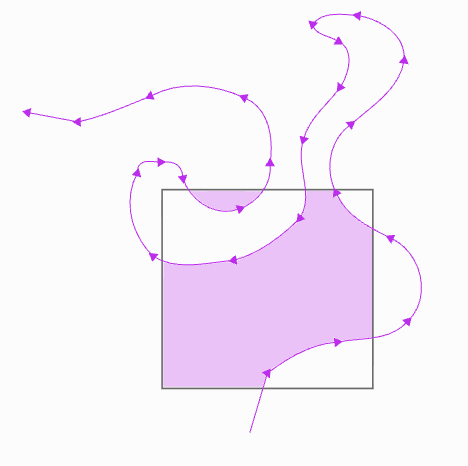


In [ ]:
# this is our function for generating time series from gridded data
def process_time_step(i,downscaled, times, time_period,rgi='Salvador',rgi_indexed=rgi_indexed,pop_density=pop_density):
    """
    Extract the population-weighted mean daily temperature for a given region
    at a given time step.

    Parameters
    ----------
    i : int
        Index of the time step to process.
    rgi : str, optional
        Name of the region of interest (matched against the 'nome_rgi' column).
        Defaults to 'Salvador'.
    times : array-like
        Array of time values corresponding to the downscaled dataset.
    rgi_indexed : GeoDataFrame
        Shapefile GeoDataFrame indexed by 'rgi' code.
    downscaled : xr.Dataset
        Downscaled temperature dataset with dimensions (time, lat, lon).
    pop_density : xr.DataArray
        Population density raster used as weights.

    Returns
    -------
    float
        Population-weighted mean temperature for the specified region
        at time step i.
    """
    # date = str(times[i])
    # print(f"Processing time step {i+1}/{len(time_period)}", end='\r', flush=True)

    # Rename coordinates
    downscaled_i = downscaled.isel(time=i).rename({"lat": "y", "lon": "x"})
    pop_renamed = pop_density.rename({"lat": "y", "lon": "x"})
    
    # select rgi of interest
    rgi_of_interest = rgi_indexed[rgi_indexed.nome_rgi == rgi]

    # Extract both unweighted and weighted means
    df = exact_extract(
        downscaled_i,
        rgi_of_interest,
        ['mean(coverage_weight=area_spherical_m2)', 'weighted_mean(coverage_weight=area_spherical_m2)'],
        weights=pop_renamed,
        output='pandas'
    )
    
    return df['weighted_mean'].values[0]


In [ ]:
######################################
# prepare data for use in the function
######################################

times = historical.time
# select period between two dates
time_period = times.sel(time=slice('2016-01-01', '2018-01-01'))
# get the integer indices of time_period within the full times array
time_indices = [int(np.where(times == t)[0][0]) for t in time_period]

####################################################
# generate timeseries data from gridded climate data
####################################################

# original resolution timeseries for comparison
salvador_timeseries_original = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, original, times, time_period, rgi='Salvador', pop_density=pop_density_original_resolution) for i in time_indices]
}, index=time_period)

# historical timeseries
salvador_timeseries_historical = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, historical, times, time_period,rgi='Salvador') for i in time_indices]
}, index=time_period)

# natural timeseries
salvador_timeseries_natural = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, natural, times, time_period, rgi='Salvador') for i in time_indices]
}, index=time_period)

# observational timeseries for comparison
salvador_timeseries_observations = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, observations, times, time_period,rgi='Salvador') for i in time_indices]
}, index=time_period)

# -----------------------------------------
# Note, this will take a few minutes to run
# -----------------------------------------

### 4. Plot the timeseries

In [ ]:
plot_timeseries(salvador_timeseries_historical, salvador_timeseries_natural)

> Here we have plotted a straighforward timeseries of the historical climate scenario vs the natural climate scenario.
>
> Climate models do not try to reproduce the exact conditions for a particular day, rather, they estimate plausible daily conditions that match the expected climate over a long period of time. Because of this we cannot directly compare the natural and the historical for particular days.
>
> To compare the two climate models, we need to look at the climatology, i.e. compare climate, not weather.

### 5. Plot the climatology

In [ ]:
plot_climatology(
    salvador_timeseries_historical,
    salvador_timeseries_natural,
    salvador_timeseries_observations,
    timeseries_original=salvador_timeseries_original,
    title='2 year climatology - Salvador'
)


> Here we have plotted an example climatology for our different climate scenarions
>
> Note, that normally we would calculate the climatology over a longer period of time (using 20 years +), but we are doing 2 years here to save on process time. 
>
> What do you notice about the climatologes of the two models? And how do they compare to the non bias corrected data and observations?

## Exercise: compare downscaled timeseries between nat and hist nat for a region of your choice
>
> #### Change the lines of code where it says "#TODO:"

In [ ]:
# examples of regions you can choose
shapefile['nome_rgi'].unique()

In [ ]:
region_name = 'Luziânia' # TODO: change to other region of interest
my_region = shapefile[shapefile['nome_rgi'] == region_name]

In [ ]:
# TODO: you can change the min (vmin) and max (vmax) values to adjust the colour bar to your region
plot_region(region_name,shapefile, original, historical,bias_not_downscaled,vmin=20,vmax=32)

In [ ]:
# original resolution timeseries for comparison
timeseries_original = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, original, times, time_period, rgi=region_name, pop_density=pop_density_original_resolution) for i in time_indices]
}, index=time_period)

# historical timeseries
timeseries_historical = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, historical, times, time_period,rgi=region_name) for i in time_indices]
}, index=time_period)

# natural timeseries
timeseries_natural = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, natural, times, time_period, rgi=region_name) for i in time_indices]
}, index=time_period)

# observational timeseries for comparison
timeseries_observations = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, observations, times, time_period,rgi=region_name) for i in time_indices]
}, index=time_period)

# note: this will take a couple of minutes to run!


In [ ]:
plot_timeseries(timeseries_historical, timeseries_natural)

In [ ]:
plot_climatology(
    timeseries_historical,
    timeseries_natural,
    timeseries_observations,
    timeseries_original=timeseries_original,
    title='2 year climatology'
)

### Questions

> How does your region compare to salvador?
>
> How would you build on this method to make it more robust?
>
> Think about limiting factors from this tutorial - if you had more compute what would you do with it?
>
> What is the natural run? Does it represent all forcings?